<a href="https://colab.research.google.com/github/utkarsha-a/ROI-detection/blob/main/02_roi_annotation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/hyper_kvasir_subset"
FRAME_DIR = os.path.join(BASE_DIR, "frames")

assert os.path.exists(FRAME_DIR), "Frames folder not found"

Mounted at /content/drive


In [ ]:
import os, random, shutil

In [ ]:
BASE_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/hyper_kvasir_subset"

FRAME_DIR = os.path.join(BASE_DIR, "frames")
ANNOT_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations"

IMG_DIR = os.path.join(ANNOT_DIR, "images")
XML_DIR = os.path.join(ANNOT_DIR, "xml")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(XML_DIR, exist_ok=True)

assert os.path.exists(FRAME_DIR), "Frames folder not found"

In [ ]:
for cls in os.listdir(FRAME_DIR):
    count = len(os.listdir(os.path.join(FRAME_DIR, cls)))
    print(f"{cls}: {count} frames")


polyp: 351 frames
inflammation: 294 frames
lesion: 126 frames
normal: 254 frames


In [ ]:
FRAMES_PER_CLASS = 60

random.seed(42)

for cls in os.listdir(FRAME_DIR):
    cls_path = os.path.join(FRAME_DIR, cls)
    frames = os.listdir(cls_path)

    sampled_frames = random.sample(
        frames,
        min(FRAMES_PER_CLASS, len(frames))
    )

    for f in sampled_frames:
        src = os.path.join(cls_path, f)
        dst = os.path.join(IMG_DIR, f)
        shutil.copy(src, dst)

print("Frames selected and copied for annotation.")


Frames selected and copied for annotation.


In [ ]:
import os

IMG_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/images"
XML_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/xml"

images = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".jpg")])
xmls = sorted([f for f in os.listdir(XML_DIR) if f.endswith(".xml")])

print("Total images:", len(images))
print("Total XML annotations:", len(xmls))

# Check filename matching
img_basenames = set(os.path.splitext(f)[0] for f in images)
xml_basenames = set(os.path.splitext(f)[0] for f in xmls)

missing_xml = img_basenames - xml_basenames
extra_xml = xml_basenames - img_basenames

print("Images without XML:", len(missing_xml))
print("XML without image:", len(extra_xml))

assert len(missing_xml) == 0, "Some images do not have XML annotations"
assert len(extra_xml) == 0, "Some XML files do not have matching images"

print("✅ Annotation dataset is consistent and ready for training.")


Total images: 239
Total XML annotations: 239
Images without XML: 0
XML without image: 0
✅ Annotation dataset is consistent and ready for training.


This figure illustrates a representative frame with manually annotated bounding box highlighting the region of interest.

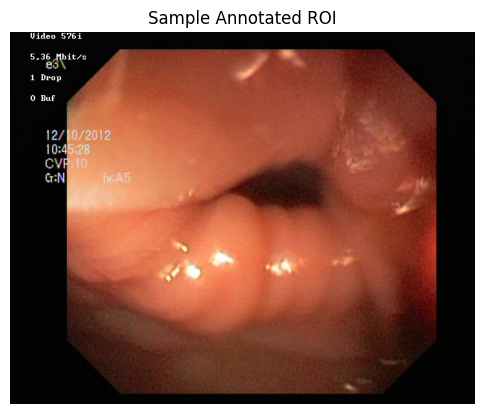

In [ ]:
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
import random

IMG_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/images"
XML_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/xml"

# Pick random annotated image
xml_file = random.choice(os.listdir(XML_DIR))
img_file = xml_file.replace(".xml", ".jpg")

img = cv2.imread(os.path.join(IMG_DIR, img_file))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

tree = ET.parse(os.path.join(XML_DIR, xml_file))
root = tree.getroot()

for obj in root.findall("object"):
    label = obj.find("name").text
    bndbox = obj.find("bndbox")
    xmin = int(bndbox.find("xmin").text)
    ymin = int(bndbox.find("ymin").text)
    xmax = int(bndbox.find("xmax").text)
    ymax = int(bndbox.find("ymax").text)

    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
    cv2.putText(img, label, (xmin, ymin-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Sample Annotated ROI")
plt.axis("off")
plt.show()

The distribution of annotated ROIs across different classes is shown in this figure, demonstrating balanced representation of major findings

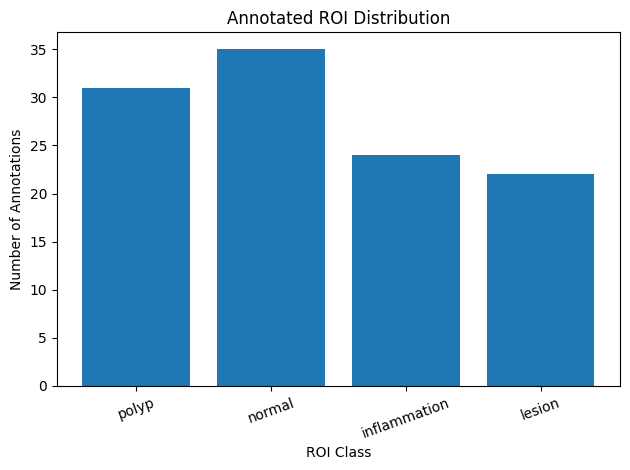

In [ ]:
from collections import Counter
import xml.etree.ElementTree as ET

label_counter = Counter()

for xml_file in os.listdir(XML_DIR):
    tree = ET.parse(os.path.join(XML_DIR, xml_file))
    root = tree.getroot()
    for obj in root.findall("object"):
        label_counter[obj.find("name").text] += 1

plt.figure()
plt.bar(label_counter.keys(), label_counter.values())
plt.xlabel("ROI Class")
plt.ylabel("Number of Annotations")
plt.title("Annotated ROI Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()